<a href="https://colab.research.google.com/github/vikranthrach/IIT-Patna--AI-and-ML-Course/blob/main/B2_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)


print("All Modules Imported")

All Modules Imported


# Load the dataset

In [ ]:
df = sns.load_dataset("titanic")
print(f"Original shape: {df.shape}")

Original shape: (891, 15)


In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [ ]:
df_clean = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked']].copy()

df_clean

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
df_clean['age'].fillna(df_clean['age'].median(), inplace = True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace = True)

/tmp/ipykernel_3534/2586001468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].median(), inplace = True)
/tmp/ipykernel_3534/2586001468.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
df_clean['sex'] = LabelEncoder().fit_transform(df_clean['sex'])

df_clean = pd.get_dummies(df_clean, columns = ['embarked'], drop_first = True)

print(f"Cleaned Shape: {df_clean.shape}")
print(f"Features: {len(df_clean.columns)-1}")
print(f"Missing Vlues: {df_clean.isnull().sum().sum()}")

Cleaned Shape: (891, 9)
Features: 8
Missing Vlues: 0


In [ ]:
df_clean

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,False,True
887,1,1,0,19.0,0,0,30.0000,False,True
888,0,3,0,28.0,1,2,23.4500,False,True
889,1,1,1,26.0,0,0,30.0000,False,False


In [ ]:
X = df_clean.drop("survived", axis = 1)
y = df_clean['survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state =42,
                                                    stratify = y)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train Target: {y_train.shape[0]} samples | Test Target: {y_test.shape[0]} samples")


Train: 712 samples | Test: 179 samples
Train Target: 712 samples | Test Target: 179 samples


# Build decision Trees

In [ ]:
dt = DecisionTreeClassifier(max_depth = 4, random_state = 42)
dt.fit(X_train,y_train )

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print(f"Single Decision Tree (Max_depth = 4)")

print("="*45)
print(f"  Train Accuracy:  {dt.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_dt):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_dt):.4f}")

Single Decision Tree (Max_depth = 4)
  Train Accuracy:  0.8413
  Test Accuracy:   0.7821
  Precision:       0.8409
  Recall:          0.5362
  F1 Score:        0.6549
  ROC-AUC:         0.7363


# Build Random Forest on the same dataset

In [ ]:
rf = RandomForestClassifier(
    n_estimators = 200, # Number of tres that we are building
    max_depth = None, # letting trees grow deep
    max_features = 'sqrt', # square root of n features per split.
    random_state = 42,
    n_jobs = -1, # You are saying that need to do parallel processing
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(f"Random Forest Tree (200 trees, default settings)")

print("="*45)
print(f"  Train Accuracy:  {rf.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_rf):.4f}")

Random Forest Tree (200 trees, default settings)
  Train Accuracy:  0.9817
  Test Accuracy:   0.8156
  Precision:       0.7903
  Recall:          0.7101
  F1 Score:        0.7481
  ROC-AUC:         0.7960


In [ ]:
# Side-by-side comparison
print("\n" + "=" * 55)
print("COMPARISON: Single Tree vs Random Forest")
print("=" * 55)
print(f"\n{'Metric':<18} {'Single Tree':>12} {'Random Forest':>14}")
print("-" * 46)
print(f"{'Train Accuracy':<18} {dt.score(X_train, y_train):>12.4f} {rf.score(X_train, y_train):>14.4f}")
print(f"{'Test Accuracy':<18} {accuracy_score(y_test, y_pred_dt):>12.4f} {accuracy_score(y_test, y_pred_rf):>14.4f}")
print(f"{'Precision':<18} {precision_score(y_test, y_pred_dt):>12.4f} {precision_score(y_test, y_pred_rf):>14.4f}")
print(f"{'Recall':<18} {recall_score(y_test, y_pred_dt):>12.4f} {recall_score(y_test, y_pred_rf):>14.4f}")
print(f"{'F1-Score':<18} {f1_score(y_test, y_pred_dt):>12.4f} {f1_score(y_test, y_pred_rf):>14.4f}")
print(f"{'ROC-AUC':<18} {roc_auc_score(y_test, y_prob_dt):>12.4f} {roc_auc_score(y_test, y_prob_rf):>14.4f}")
print(f"\n>>> Random Forest wins on every metric!")


COMPARISON: Single Tree vs Random Forest

Metric              Single Tree  Random Forest
----------------------------------------------
Train Accuracy           0.8413         0.9817
Test Accuracy            0.7821         0.8156
Precision                0.8409         0.7903
Recall                   0.5362         0.7101
F1-Score                 0.6549         0.7481
ROC-AUC                  0.8070         0.8377

>>> Random Forest wins on every metric!


In [ ]:
rf2 = RandomForestClassifier(
    n_estimators = 500, # Number of tres that we are building
    max_depth = 10, # letting trees grow deep
    max_features = 'sqrt', # square root of n features per split.
    random_state = 42,
    n_jobs = -1, # You are saying that need to do parallel processing
)

rf2.fit(X_train,y_train)

y_pred_rf2 = rf2.predict(X_test)
y_prob_rf2 = rf2.predict_proba(X_test)[:,1]

print(f"Random Forest Tree (200 trees, default settings)")

print("="*45)
print(f"  Train Accuracy:  {rf2.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_rf2):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_rf2):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_rf2):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_rf2):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_rf2):.4f}")

Random Forest Tree (200 trees, default settings)
  Train Accuracy:  0.9466
  Test Accuracy:   0.8045
  Precision:       0.7931
  Recall:          0.6667
  F1 Score:        0.7244
  ROC-AUC:         0.7788


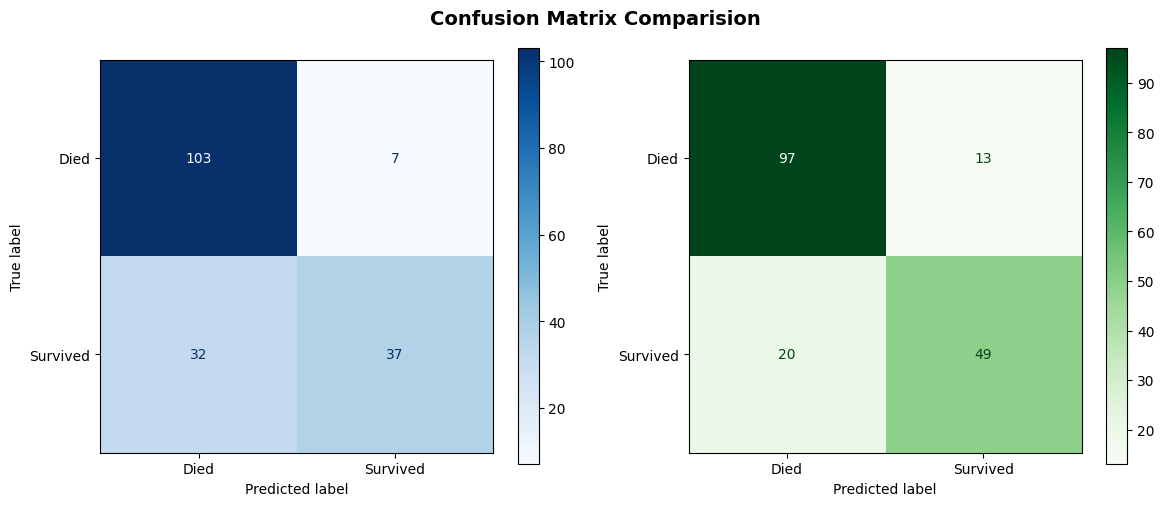

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred_dt,
                                        display_labels = ['Died', 'Survived'],
                                        cmap = "Blues",
                                        ax=axes[0])
ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred_rf,
                                        display_labels = ['Died', 'Survived'],
                                        cmap = "Greens",
                                        ax=axes[1])
plt.suptitle("Confusion Matrix Comparision", fontsize = 14, fontweight = "bold")
plt.tight_layout()
plt.show()


# Model saving

In [ ]:
rf

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")
print("Model Saved!")

Model Saved!


# Load the model train

In [ ]:
loaded_model = joblib.load("random_forest_model.pkl")

In [ ]:
loaded_model

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
predicitons = loaded_model.predict(X_test)
print(predicitons)

[0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 1 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 1
 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0
 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0]


In [ ]:
# Feature importance comparison: Single Tree vs Random Forest
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Single Tree': dt.feature_importances_,
    'Random Forest': rf.feature_importances_
}).sort_values('Random Forest', ascending=False)

print("Feature Importance Comparison:")
print("=" * 50)
print(importance_df.to_string(index=False))

Feature Importance Comparison:
   Feature  Single Tree  Random Forest
      fare     0.054002       0.278190
       sex     0.576297       0.259463
       age     0.116096       0.249474
    pclass     0.195920       0.089805
     sibsp     0.012109       0.048112
     parch     0.008377       0.039833
embarked_S     0.037198       0.024867
embarked_Q     0.000000       0.010256


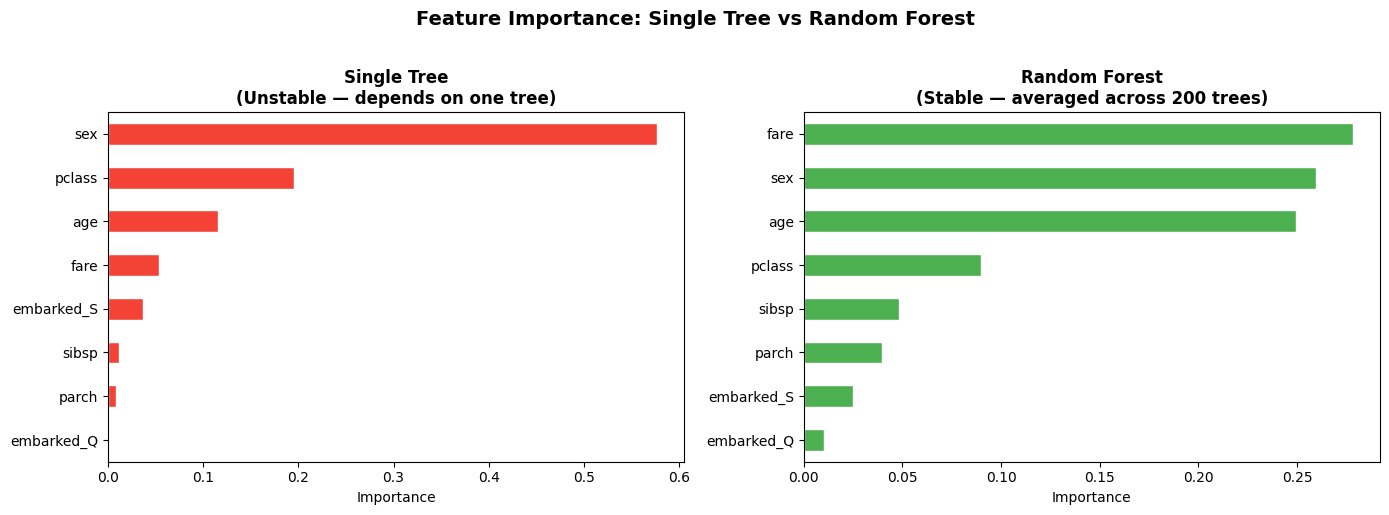

In [ ]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single Tree
ax = axes[0]
imp_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values()
imp_dt.plot(kind='barh', ax=ax, color='#F44336', edgecolor='white')
ax.set_title('Single Tree\n(Unstable — depends on one tree)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')

# Random Forest
ax = axes[1]
imp_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp_rf.plot(kind='barh', ax=ax, color='#4CAF50', edgecolor='white')
ax.set_title('Random Forest\n(Stable — averaged across 200 trees)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')

plt.suptitle('Feature Importance: Single Tree vs Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()